### Applied Machine Learning Project

##### Name: Sayed Saidoo

##### Dataset: Airline Passenger Satisfaction

##### Project Overview:

This project applies machine learning techniques to the `Airline Passenger Satisfaction` dataset to predict whether a passenger is satisfied or dissatisfied with their overall travel experience. The dataset contains demographic information, travel characteristics, and customer service ratings collected from airline passengers.

The primary objective of this project is to develop and evaluate classification models capable of predicting passenger satisfaction while following a complete and reproducible machine learning workflow. The analysis includes data preparation, exploratory data analysis, feature preprocessing, model training, performance evaluation, and interpretation of results.

The study focuses on the following research question:

*Can passenger satisfaction be accurately predicted using customer demographics, travel characteristics, and service quality ratings?*

To address this question, multiple classification algorithms will be evaluated and compared using appropriate performance metrics. Model explainability techniques will be used to identify the most important factors influencing predictions, and fairness assessment methods will be applied to investigate potential performance disparities across passenger groups.


### Setup Core Dependencies

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
from typing import Any

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import warnings
#warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Scikit-Learn Pipeline Components
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config

# Data Splitting
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Pipeline Visualization
set_config(display="diagram")

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Model Evaluation function
def evaluate_classification_model(
    model_name: str,
    model: Any,
    X_test: pd.DataFrame,
    y_test: pd.Series
) -> pd.DataFrame:
    """
    Evaluate a trained classification model and return
    performance metrics as a comparison-ready DataFrame.
    """

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return pd.DataFrame(
        {
            "Model": [model_name],
            "Accuracy": [accuracy_score(y_test, y_pred)],
            "Precision": [precision_score(y_test, y_pred)],
            "Recall": [recall_score(y_test, y_pred)],
            "F1 Score": [f1_score(y_test, y_pred)],
            "ROC-AUC": [roc_auc_score(y_test, y_prob)]
        }
    ).round(4)

In [3]:
# Reusable descriptive statistics function
def generate_descriptive_statistics(dataframe: pd.DataFrame, include: str | None = None) -> pd.DataFrame:
    """
    Generate descriptive statistics for a pandas DataFrame.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataset to summarize.
    include : str | None, default=None
        Column types to include in the summary.
        Examples: "number", "object", "all".

    Returns
    -------
    pd.DataFrame
        Descriptive statistics summary table.
    """
    return dataframe.describe(include=include).T

### Data Ingestion and Inspection

In [4]:
train_df = pd.read_csv("./data/train.csv")
test_df = pd.read_csv("./data/test.csv")

print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape: {test_df.shape}")

Training Set Shape: (103904, 25)
Testing Set Shape: (25976, 25)


In [5]:
train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
test_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [8]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  F

In [9]:
# Check for missing values and Dupliates
print("Duplicate Rows:", train_df.duplicated().sum())
print("\nMissing Value Percentage %:")
missing_pct = train_df.isnull().mean() * 100
top_missing = missing_pct.sort_values(ascending=False).head(2)

# Format each value to 2 decimal places with a percentage sign
print(top_missing.map("{:,.2f}%".format))

Duplicate Rows: 0

Missing Value Percentage %:
Arrival Delay in Minutes    0.30%
id                          0.00%
dtype: str


In [10]:
print("Duplicate Rows:", test_df.duplicated().sum())
print("\nMissing Value Percentage %:")
missing_pct = test_df.isnull().mean() * 100
top_missing = missing_pct.sort_values(ascending=False).head(2)

# Format each value to 2 decimal places with a percentage sign
print(top_missing.map("{:,.2f}%".format))

Duplicate Rows: 0

Missing Value Percentage %:
Arrival Delay in Minutes    0.32%
id                          0.00%
dtype: str


In [11]:
generate_descriptive_statistics(train_df)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0


In [12]:
generate_descriptive_statistics(train_df, include="str")

,count,unique,top,freq
Gender,103904,2,Female,52727
Customer Type,103904,2,Loyal Customer,84923
Type of Travel,103904,2,Business travel,71655
Class,103904,3,Business,49665
satisfaction,103904,2,neutral or dissatisfied,58879


In [13]:
generate_descriptive_statistics(test_df)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,25976.0,12987.500000,7498.769632,0.0,6493.75,12987.5,19481.25,25975.0
id,25976.0,65005.657992,37611.526647,17.0,32170.50,65319.5,97584.25,129877.0
Age,25976.0,39.620958,15.135685,7.0,27.00,40.0,51.00,85.0
Flight Distance,25976.0,1193.788459,998.683999,31.0,414.00,849.0,1744.00,4983.0
Inflight wifi service,25976.0,2.724746,1.335384,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,25976.0,3.046812,1.533371,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,25976.0,2.756775,1.412951,0.0,2.00,3.0,4.00,5.0
Gate location,25976.0,2.977094,1.282133,1.0,2.00,3.0,4.00,5.0
Food and drink,25976.0,3.215353,1.331506,0.0,2.00,3.0,4.00,5.0
Online boarding,25976.0,3.261665,1.355536,0.0,2.00,4.0,4.00,5.0


In [14]:
generate_descriptive_statistics(test_df, include="str")

,count,unique,top,freq
Gender,25976,2,Female,13172
Customer Type,25976,2,Loyal Customer,21177
Type of Travel,25976,2,Business travel,18038
Class,25976,3,Business,12495
satisfaction,25976,2,neutral or dissatisfied,14573


In [15]:
# Calculate the percentage distribution for target variable
train_df['satisfaction'].value_counts(normalize=True) * 100


satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64

In [16]:
test_df['satisfaction'].value_counts(normalize=True) * 100

satisfaction
neutral or dissatisfied    56.101786
satisfied                  43.898214
Name: proportion, dtype: float64

##### Initial Inspection Summary

The dataset contains 103,904 observations in the training set and 25 features describing passenger demographics, travel characteristics, service quality ratings, flight delays, and overall satisfaction. Test set contains 25,976 observations which represents a good percentage split for model training.

Initial inspection revealed that the dataset is generally clean and well-structured for machine learning. No duplicate records were identified in either the training or testing datasets, and data types appear appropriate for their respective variables.

A single feature, `Arrival Delay in Minutes`, contains missing values (310 records), representing less than 1% of the training dataset. This issue will be addressed during the preprocessing stage using an appropriate imputation strategy.

Several categorical variables are present, including passenger gender, customer type, travel type, and travel class. These variables will require encoding prior to model training. The remaining features consist primarily of numerical demographic, travel, and service rating attributes. Some categorical features may be converted to `category` data types for downstream workflow optimization.

Two variables, `Unnamed: 0` and `id`, appear to function as identifiers rather than meaningful predictive features. These columns will be investigated further and may be removed prior to modeling if they are confirmed to contain no predictive information.

##### Descriptive Statistics Summary

The categorical variables exhibit relatively low cardinality, with Gender, Customer Type, Type of Travel, and the target variable (satisfaction) each containing two categories, while Class contains three categories. This low-cardinality structure is well-suited for categorical encoding during preprocessing.

The numerical features display reasonable distributions overall. Passenger ages range from 7 to 85 years, with a median age of 40 years, indicating representation across multiple age groups. Flight distances vary considerably, ranging from 31 to 4,983 miles, suggesting that both short-haul and long-haul travel are represented in the dataset. Service quality variables are measured on a 0-5 rating scale and generally exhibit median values between 3 and 4, indicating moderate to favorable customer evaluations across most service categories.

The target variable shows a relatively balanced distribution, with approximately 56.7% of passengers classified as *neutral or dissatisfied* and 43.3% classified as *satisfied*. This distribution is appropriate for supervised classification and should support meaningful model evaluation without severe class imbalance concerns.

Comparison with the testing dataset indicates a high degree of consistency across both categorical and numerical variables. Feature cardinality remains unchanged, and key numerical measures such as means, medians, standard deviations, and ranges closely mirror those observed in the training data. The class distribution is also nearly identical, with approximately 56.1% of testing observations classified as *neutral or dissatisfied* and 43.9% classified as *satisfied*. This similarity suggests that the provided train-test split is representative of the same underlying population and should provide a reliable basis for model development and evaluation.

### Data Preparation and Preprocessing

##### Handling High Cardinality Columns such as 'ID'

In [17]:
print(f"Unique ID Feature in training set: {train_df['id'].nunique():,}")
print(f"Unique 'Unnamed:0' in training set: {train_df['Unnamed: 0'].nunique():,}")
print(f"-----Training records: {len(train_df):,}-----")

print(f"Unique ID Feature in testing set: {test_df['id'].nunique():,}")
print(f"Unique 'Unnamed:0' in testing set: {test_df['Unnamed: 0'].nunique():,}")
print(f"-----Testing records: {len(test_df):,}-----")

Unique ID Feature in training set: 103,904
Unique 'Unnamed:0' in training set: 103,904
-----Training records: 103,904-----
Unique ID Feature in testing set: 25,976
Unique 'Unnamed:0' in testing set: 25,976
-----Testing records: 25,976-----


##### High Cardinality Feature Removal

Initial inspection identified two identifier-like features (`Unnamed: 0` and `id`) that do not contain meaningful passenger characteristics and are unlikely to provide predictive value. To ensure preprocessing remains fully reproducible and reusable, a custom transformation step will be incorporated into the preprocessing pipeline to remove these columns automatically during model training and inference.

##### Missing Value Assessment from Data Inspection Section

Missing value analysis revealed that only one feature, `Arrival Delay in Minutes`, contains missing observations. Specifically, 310 records (approximately 0.3% of the training dataset) have missing values for this variable.

Because the proportion of missing data is very small, removing affected observations would likely have minimal impact. However, retaining all available records is preferable given the large dataset size.

The delay related features exhibit substantial variability and contain extreme values, suggesting that median imputation is more appropriate than mean imputation, as it is less sensitive to outliers. To support a reproducible machine learning workflow and avoid data leakage, missing values will be handled within the preprocessing pipeline using median imputation rather than modifying the raw dataset directly.

##### Feature Group Assessment

In [18]:
categorical_features = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

numerical_features = [
    col for col in train_df.columns
    if col not in categorical_features
]

print(f"Categorical Features ({len(categorical_features)}):")
print(categorical_features)

print(f"\nNumerical Features ({len(numerical_features)}):")
print(numerical_features)

Categorical Features (5):
['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Numerical Features (20):
['Unnamed: 0', 'id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [19]:
# Possible transformation inplace (data type casting)
# for column in categorical_features:
#     train_df[column] = train_df[column].astype("category")
#     test_df[column] = test_df[column].astype("category")
# train_df[categorical_features].dtypes

##### Feature Data Type Assessment

Initial inspection identified a small number of low-cardinality categorical variables represented as string data types. These features contain a limited number of distinct categories and are appropriate candidates for conversion to the `category` data type.

Converting these variables to categorical data types can improve memory efficiency and clearly distinguish categorical features from numerical variables during preprocessing. This distinction will also facilitate the construction of separate preprocessing pipelines for categorical and numerical features.

The target variable (`satisfaction`) will also be encoded during the modeling stage to support binary classification.


##### Handling Numerical Data

In [20]:
# Feature Lists for numerical data groups
# We intentionally omit the id features because we know these will be dropped
continuous_features = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]
ordinal_features = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

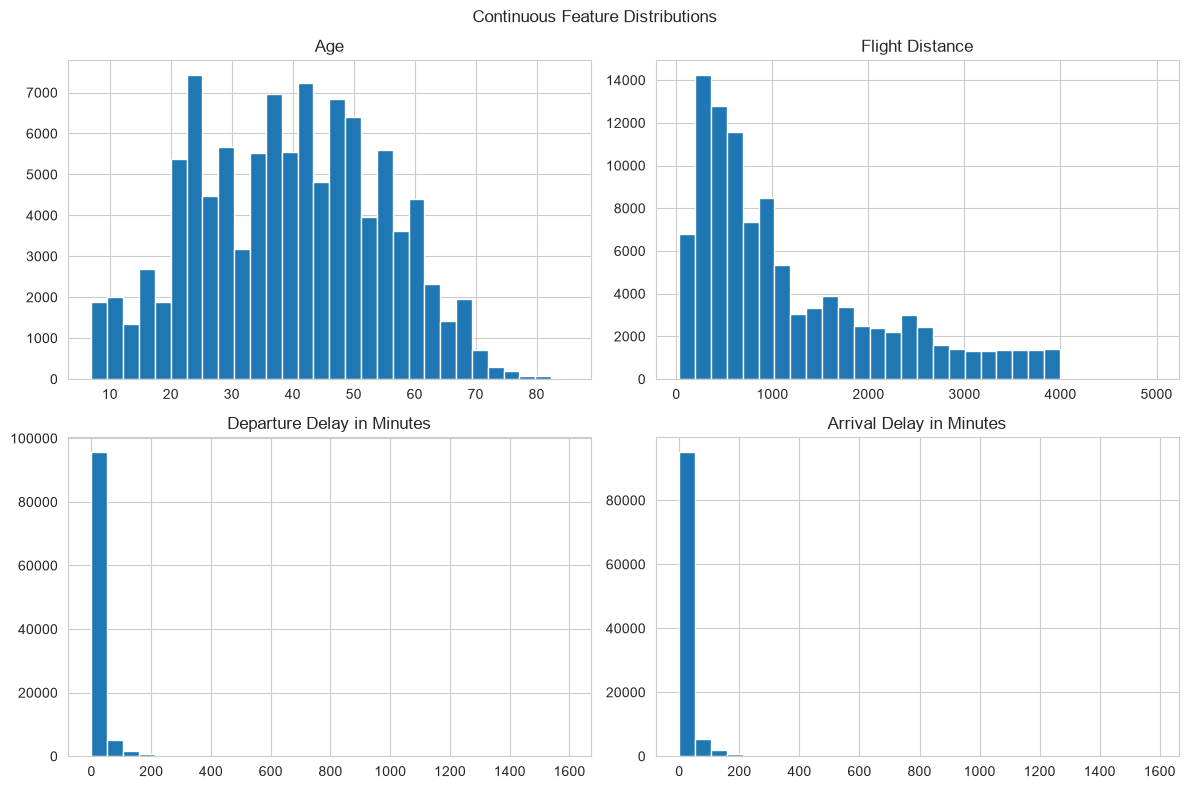

In [21]:
train_df[continuous_features].hist(
    bins=30,
    figsize=(12, 8)
)

plt.suptitle("Continuous Feature Distributions")
plt.tight_layout()
plt.show()

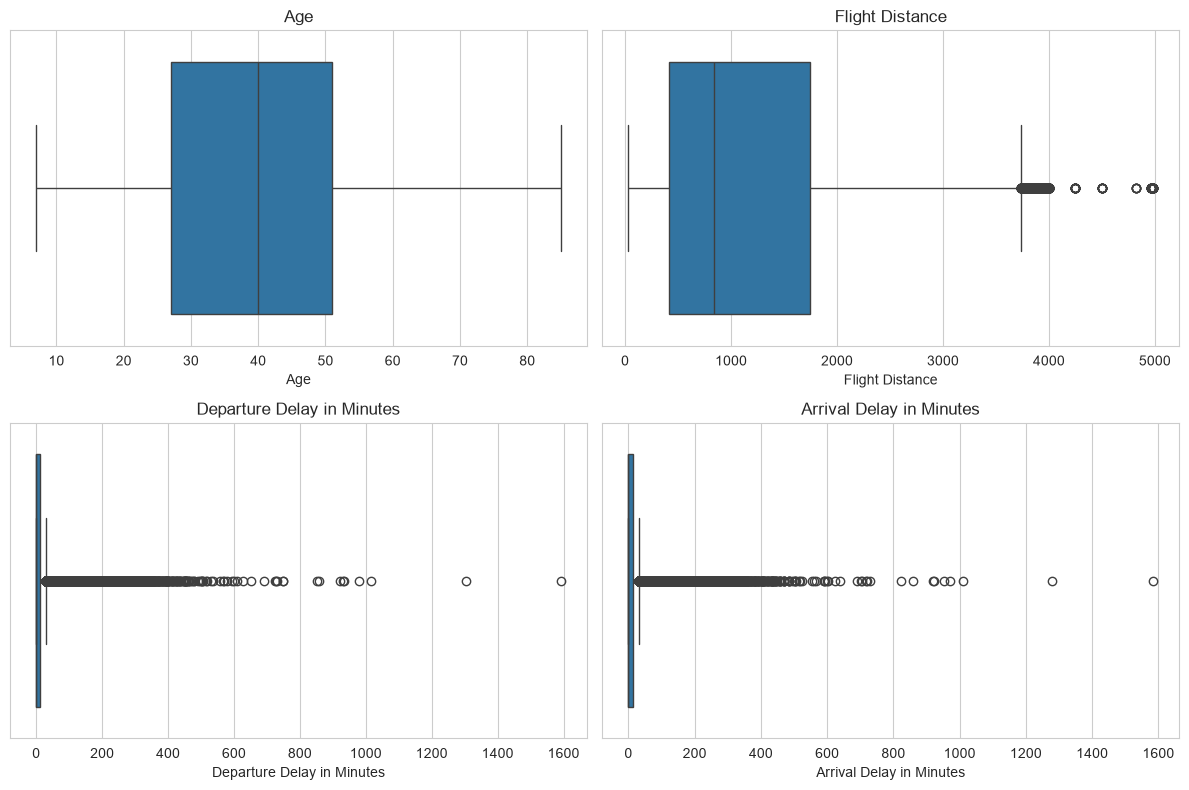

In [22]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

for ax, feature in zip(
    axes.flatten(),
    continuous_features
):
    sns.boxplot(
        x=train_df[feature],
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [23]:
skewness_df = pd.DataFrame(
    {
        "Skewness": train_df[
            continuous_features
        ].skew()
    }
).sort_values(
    by="Skewness",
    ascending=False
)

skewness_df

,Skewness
Departure Delay in Minutes,6.733980
Arrival Delay in Minutes,6.596637
Flight Distance,1.109466
Age,-0.004516


##### Continuous Feature Assessment

Visual inspection and skewness analysis of the continuous variables revealed distinct distributional characteristics across the dataset.

Passenger age appears approximately normally distributed, with a skewness value close to zero (-0.005), indicating a largely symmetric distribution. No substantial outliers or unusual patterns were observed, and no transformation is currently considered necessary for this feature.

Flight distance exhibits moderate positive skew (skewness = 1.11) and contains several high-value observations in the upper tail of the distribution. However, these observations appear operationally plausible and likely represent legitimate long-haul flights rather than data quality concerns. Consequently, no outlier treatment is currently planned.

The departure and arrival delay features display substantial positive skew (6.73 and 6.60 respectively), with median values of zero minutes indicating that most flights experience little or no delay. Both variables contain extreme high-end observations representing severe travel disruptions. While these observations would be considered statistical outliers, they are likely genuine operational events and may provide valuable predictive information regarding passenger satisfaction.

Given the apparent validity of these observations, no outlier removal is currently planned. Standardization will be considered within the preprocessing pipeline, while potential transformations e.g. log transformations, will only be evaluated if subsequent modeling results suggest a clear performance benefit. Preserving the original distributions at this stage also supports interpretability and retains potentially important information about extreme customer experiences.

In [24]:
for feature in ordinal_features:
    print(
        f"{feature}: "
        f"{sorted(train_df[feature].unique())}"
    )

Inflight wifi service: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Departure/Arrival time convenient: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Ease of Online booking: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Gate location: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Food and drink: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Online boarding: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Seat comfort: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Inflight entertainment: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
On-board service: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Leg room service: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Baggag

##### Ordinal Feature Assessment

The dataset contains multiple service related survey response variables measured on an ordinal rating scale. Most features use a rating range of 0 to 5, while `Baggage handling` uses a range of 1 to 5. These variables represent ordered evaluations of different aspects of the passenger experience and therefore contain meaningful ordinal information.

Because the ordering between values is informative, these features will be retained as ordinal numerical variables rather than transformed into categorical variables and one-hot encoded. Preserving the ordinal structure allows machine learning models to utilize the relative relationship between rating levels while avoiding unnecessary feature expansion.

Scaling may be considered during model development for algorithms that are sensitive to feature magnitude, such as Logistic Regression or other distance or optimization-based methods.

##### Preprocessing Pipeline

In [25]:
# remove target variable from feature list
categorical_features = [
"Gender",
"Customer Type",
"Type of Travel",
"Class"
]

In [26]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [27]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "drop_identifiers",
            "drop",
            ["Unnamed: 0", "id"]
        ),
        (
            "continuous",
            numeric_pipeline,
            continuous_features
        ),
        (
            "ordinal",
            "passthrough",
            ordinal_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

##### Baseline Preprocessing Pipeline

The baseline preprocessing pipeline implements only transformations that were justified through data inspection and quality assessment. Additional preprocessing strategies, such as feature scaling or logarithmic transformations, may be evaluated later during model development to determine whether they provide measurable performance improvements.

### Select and Train a Machine Learning Model

In [29]:
# Separate predictors and target

X_train = train_df.drop(columns=["satisfaction"])
y_train = train_df["satisfaction"]

X_test = test_df.drop(columns=["satisfaction"])
y_test = test_df["satisfaction"]

In [30]:
# Encode target variable

target_mapping = {
    "neutral or dissatisfied": 0,
    "satisfied": 1
}

y_train = y_train.map(target_mapping)
y_test = y_test.map(target_mapping)

In [31]:
# Quick Sanity check that encoding was successfull
pd.DataFrame(
    {
        "Training": y_train.value_counts(normalize=True),
        "Testing": y_test.value_counts(normalize=True)
    }
).round(4)

,Training,Testing
satisfaction,,
0,0.5667,0.561
1,0.4333,0.439


##### Baseline Logistic Regression Model

In [32]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [33]:
logistic_pipeline.fit(X_train, y_train)

c:\Users\shehz\anaconda3\envs\statistical_analysis\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['Unnamed: 0','id','Gender',...,'Cleanliness','Departure Delay in Minutes', 'Arrival Delay in Minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('drop_identifiers', ...), ('continuous', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default 

In [34]:
logistic_pipeline.named_steps["classifier"]

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

##### Baseline Random Forest Model

In [35]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [36]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['Unnamed: 0','id','Gender',...,'Cleanliness','Departure Delay in Minutes', 'Arrival Delay in Minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('drop_identifiers', ...), ('continuous', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default 

In [37]:
rf_pipeline.named_steps["classifier"]

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

##### Model Selection Basis

Two machine learning algorithms were selected to establish baseline performance for predicting airline passenger satisfaction.

Logistic Regression was chosen as an interpretable baseline classifier for binary classification. The model provides a well-established benchmark that enables straightforward interpretation of relationships between predictor variables and the target outcome. Its simplicity makes it useful for determining whether passenger satisfaction can be adequately modeled using predominantly linear relationships. The model however, generated a convergence warning, suggesting that feature scale differences may be affecting optimization. This observation motivates the evaluation of feature scaling as a potential improvement during the model evaluation phase

Random Forest was selected as an ensemble learning method capable of capturing complex nonlinear relationships and interactions between features. Passenger satisfaction is likely influenced by combinations of service quality ratings, travel characteristics, and delay-related factors that may not be fully represented by a linear model. Random Forest can model these relationships while remaining relatively robust to outliers and varying feature distributions.

Comparing the performance of these two models provides insight into whether a simpler interpretable model is sufficient or whether a more flexible nonlinear approach better represents the underlying patterns in the data.

### Model Evaluation and Interpretation

In [39]:
logistic_results = evaluate_classification_model(
    model_name="Logistic Regression",
    model=logistic_pipeline,
    X_test=X_test,
    y_test=y_test
)

rf_results = evaluate_classification_model(
    model_name="Random Forest",
    model=rf_pipeline,
    X_test=X_test,
    y_test=y_test
)

In [40]:
baseline_results = pd.concat(
    [
        logistic_results,
        rf_results
    ],
    ignore_index=True
)

baseline_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8706,0.8658,0.8345,0.8499,0.9257
1,Random Forest,0.9630,0.9721,0.9428,0.9573,0.9943
